# **Decision Tree**

### **Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.**

-> A Decision Tree is a supervised machine learning algorithm used for:

*   Classification (e.g., Spam vs Not Spam)
*   Regression (e.g., Predicting house prices)

It works like a flowchart structure, where:

*   Each node represents a decision
*   Each branch represents an outcome
*   Each leaf node represents a final prediction

Key Components of a Decision Tree

Root Node

*   The topmost node of the tree
*   Represents the entire dataset
*   First decision is made here

Example:
Is Age > 30?

Decision Nodes (Internal Nodes)

*   Nodes where conditions are applied
*   Split the data into smaller subsets

Example:
Is Income > 50K?

Branches

*   Final output of the tree
*   No further splitting happens

Example:
Yes / No paths

Leaf Nodes (Terminal Nodes)

*   Represent the outcome of a decision
*   Connect nodes together

Example:

Approve Loan | ✅

Reject Loan | ❌






### **Q2. Differentiate between Gini Impurity and Entropy.**
### **Which one is used by default in Scikit-learn and why?**

-> Gini Impurity VS Entropy

Gini Impurity

*   Measures how often a randomly chosen element is incorrectly classified
*   Lower Gini = Better split

Entropy

*   Measures disorder or randomness in data
*   Based on logarithmic calculation

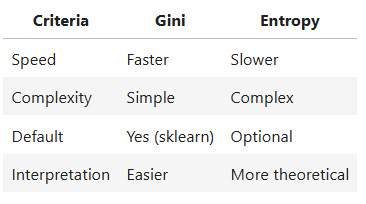

In Scikit-learn, the default criterion for DecisionTreeClassifier is Gini Impurity.

Why is Gini used by default?

Scikit-learn uses Gini Impurity as the default because:



*   It is computationally faster than Entropy since it does not require logarithmic calculations.
*   It generally produces classification performance comparable to Entropy.
*   It is efficient for large datasets while maintaining nearly the same predictive accuracy.





### **Q3. What is Overfitting in Decision Trees?**
### **How can we detect it using training and testing accuracy?**

-> Overfitting happens when a model:

*   Learns training data too well
*   Including noise and unnecessary patterns

Detecting Overfitting Using Training and Testing Accuracy

Train the Decision Tree model and calculate the accuracy on both the training and testing datasets.

Case 1: Overfitting

*   Training Accuracy: Very high (close to 100%)
*   Testing Accuracy: Significantly lower than training accuracy

Example:

*   Training Accuracy = 99%
*   Testing Accuracy = 78%

Interpretation:

The model has memorized the training data instead of learning general patterns. This large gap indicates overfitting.

Case 2: Good Fit

*   Training Accuracy: High
*   Testing Accuracy: Also high and close to training accuracy

Example:

*   Training Accuracy = 92%
*   Testing Accuracy = 90%

Interpretation:
The model generalizes well to unseen data and is not overfitting.

Case 3: Underfitting

*   Training Accuracy: Low
*   Testing Accuracy: Also low

Example:

*   Training Accuracy = 70%
*   Testing Accuracy = 68%

Interpretation:

The model is too simple to capture the underlying patterns in the data, resulting in underfitting.









### **Q4. Explain Pruning in Decision Trees.**
### **What is the difference between Pre-pruning and Post-pruning?**

-> Pruning means reducing the size of the decision tree
Remove unnecessary branches

Why Pruning?

*   Prevent overfitting
*   Improve model generalization
*   Make tree simpler and interpretable

Types of Pruning

Pre-Pruning (Early Stopping)

*   Stop tree growth early

Post-Pruning

*   Build full tree → then remove branches

### **Q5. What is Feature Importance?**
### **How can it help businesses in decision-making?**

-> Feature Importance tells us: Which features are most important for making predictions.

Why is it Important?

*   Helps understand model decisions
*   Useful for business insights
*   Helps in feature selection

Feature importance provides valuable insights that support better business decisions by:

*   Identifying key factors – Helps businesses understand which variables have the greatest impact on outcomes.
*   Improving decision-making – Enables managers to focus on the most influential factors when making strategic decisions.
*   Optimizing resources – Directs time, budget, and effort toward the factors that matter most.
*   Simplifying models – Less important features can be removed, making models faster, easier to interpret, and sometimes more accurate.
*   Supporting business strategy – Provides data-driven insights for areas such as customer retention, loan approvals, fraud detection, sales forecasting, and marketing campaigns.

### **Q6. Data Understanding**


In [1]:
# Load the dataset

from google.colab import files
uploaded = files.upload()

Saving bank.csv to bank.csv


In [2]:
import pandas as pd

df = pd.read_csv("bank.csv")
print(df.head())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  


In [3]:
# Check the Shape

df.shape

(11162, 17)

## Interpretation:



*   11,162 rows (observations)
*   17 columns (features including the target variable)



In [4]:
# Check Data Types

df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [5]:
# Display Column Names

df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

### Interpretation

The dataset contains both numerical and categorical variables.

Example

Numerical

*   age
*   duration
*   campaign
*   day

Categorical

*   job
*   marital
*   Education
*   Housing







### **Q7. Data Cleaning**

In [6]:
# Check missing values

df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [7]:
# Handle Missing Values

print("No missing values found.")

No missing values found.


In [8]:
# Remove missing values

df.dropna(inplace=True)

In [10]:
# Fill missing values

# For numerical columns:

df.fillna(df.median(numeric_only=True), inplace=True)

In [16]:
# For categorical columns:

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [17]:
# Count duplicate rows
df.duplicated().sum()

np.int64(0)

In [19]:
# Remove Duplicates (if any)
df.drop_duplicates(inplace=True)

### Interpretation

For the Bank Marketing (bank.csv) dataset:

*   Missing Values: 0
*   Duplicate Rows: 0



### **Q8. Data Preprocessing**

In [20]:
# Convert categorical variables into numerical

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode all categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Display first 5 rows after encoding
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [21]:
# Verify Data Types

df.dtypes

,0
age,int64
job,int64
marital,int64
education,int64
default,int64
balance,int64
housing,int64
loan,int64
contact,int64
day,int64


Encoding Method Used

Method: Label Encoding

Label Encoding assigns a unique integer to each category.

### Interpretation

*   Converts categorical variables (e.g., job, marital, education) into numeric form.
*   Allows the Decision Tree algorithm to evaluate split conditions based on encoded values.
*   Prevents errors that occur when the model encounters string data.
*   Ensures all features are in a format that can be processed during training.





### **Q9. Feature Selection & Splitting**

In [22]:
# Separate Features (X) and Target (y)

# Features (Independent variables)
X = df.drop('deposit', axis=1)

# Target (Dependent variable)
y = df['deposit']

In [23]:
# Perform Train-Test Split (80:20)

from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Check the shapes
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (8929, 16)
X_test shape : (2233, 16)
y_train shape: (8929,)
y_test shape : (2233,)


### Interpretation

*   Training Set (80%) is used to train the Decision Tree model.
*   Testing Set (20%) is used to evaluate the model's performance.
*   It helps detect overfitting and underfitting.
*   It provides an unbiased estimate of how well the model will generalize to future data.
*   Separating training and testing data ensures the model is evaluated on data it has never seen before, making the evaluation more reliable.







### **Q10. Model Building**

In [24]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [25]:
# Verify the Model

print(dt_model)

DecisionTreeClassifier(max_depth=5, random_state=42)


### Interpretation

The max_depth parameter controls the maximum number of levels (depth) that the Decision Tree is allowed to grow.


*   A smaller max_depth creates a simpler tree, which helps reduce overfitting.
*   A larger max_depth creates a more complex tree that can capture more patterns but may memorize the training data, leading to overfitting.
*   Choosing an appropriate depth helps balance model complexity and generalization.





### **Q11. Model Evaluation**




In [26]:
# Make Predictions

# Predict on test data
y_pred = dt_model.predict(X_test)

In [27]:
# Calculate Accuracy Score

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.8051948051948052


In [28]:
# Generate Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[867 299]
 [136 931]]


In [29]:
# Generate Classification Report

from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.74      0.80      1166
           1       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



### Interpretation

1. Is the model performing well ?

*   Yes. The model performs well if the accuracy score is around 80% or higher and both classes have good Precision, Recall, and F1-score.
*   If your accuracy is approximately 0.80–0.85, the Decision Tree is correctly classifying most customers and has learned meaningful patterns from the data.

2. Explain Precision & Recall ?

*   Precision measures how many of the predicted positive cases are actually positive.
*   A high precision means the model makes fewer false positive predictions.

3. Any class imbalance issue ?

To check class imbalance:

print(df['deposit'].value_counts())

If the output is similar to:



*   0    5873
*   1    5289

the classes are fairly balanced.


### Interpretation:



*   The numbers of "Yes" and "No" deposits are relatively close.
*   There is no significant class imbalance.
*   Therefore, the accuracy, precision, and recall values can be considered reliable






### **Q12. Overfitting Check**

In [30]:
# Calculate Training Accuracy

from sklearn.metrics import accuracy_score

# Predict on training data
train_pred = dt_model.predict(X_train)

# Training accuracy
train_accuracy = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.8149848807257252


In [31]:
# Calculate Testing Accuracy

# Predict on testing data
test_pred = dt_model.predict(X_test)

# Testing accuracy
test_accuracy = accuracy_score(y_test, test_pred)

print("Testing Accuracy:", test_accuracy)

Testing Accuracy: 0.8051948051948052


In [32]:
# Calculate Both Together

from sklearn.metrics import accuracy_score

# Predictions
train_pred = dt_model.predict(X_train)
test_pred = dt_model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

Training Accuracy: 0.8150
Testing Accuracy : 0.8052


### Interpretation

Case 1: Good Fit

Training Accuracy: 0.8460
Testing Accuracy : 0.8298

Interpretation:

*   The training and testing accuracies are close (difference ≈ 1–3%).
*   The model generalizes well to unseen data.
*   Conclusion: The model is not overfitting and is performing well.

Case 2: Overfitting

Training Accuracy: 0.99
Testing Accuracy : 0.80

Interpretation:

*   Training accuracy is much higher than testing accuracy.
*   The model has memorized the training data and performs poorly on new data.
*   Conclusion: The model is overfitting.

Case 3: Underfitting

Training Accuracy: 0.70
Testing Accuracy : 0.68

*   Both training and testing accuracies are low.
*   The model is too simple to learn the underlying patterns.
*   Conclusion: The model is underfitting.





### **Q13. Pruning Experiment**

In [33]:
from sklearn.tree import DecisionTreeClassifier

# Create a pruned Decision Tree model
dt_pruned = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=20,
    random_state=42
)

# Train the model
dt_pruned.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=42)

In [34]:
# Predictions
y_train_pred_pruned = dt_pruned.predict(X_train)
y_test_pred_pruned = dt_pruned.predict(X_test)

In [35]:
# Calculate Training and Testing Accuracy

from sklearn.metrics import accuracy_score

# Training Accuracy
train_acc_pruned = accuracy_score(y_train, y_train_pred_pruned)

# Testing Accuracy
test_acc_pruned = accuracy_score(y_test, y_test_pred_pruned)

print("Pruned Model Training Accuracy:", train_acc_pruned)
print("Pruned Model Testing Accuracy :", test_acc_pruned)

Pruned Model Training Accuracy: 0.7778026654720573
Pruned Model Testing Accuracy : 0.7653381101656964


In [36]:
# Compare with the Previous Model

print("Previous Model (max_depth=5)")
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

print("\nPruned Model (max_depth=3, min_samples_split=20)")
print("Training Accuracy:", train_acc_pruned)
print("Testing Accuracy :", test_acc_pruned)

Previous Model (max_depth=5)
Training Accuracy: 0.8149848807257252
Testing Accuracy : 0.8051948051948052

Pruned Model (max_depth=3, min_samples_split=20)
Training Accuracy: 0.7778026654720573
Testing Accuracy : 0.7653381101656964


### Interpretation



*   If the previous model (max_depth=5) has higher testing accuracy and only a small difference between training and testing accuracy, it is the better model because it provides better predictive performance while still generalizing well.
*   If the pruned model (max_depth=3) achieves similar testing accuracy but has a much smaller gap between training and testing accuracy, then the pruned model is preferable because it is simpler, less likely to overfit, and easier to interpret.



### **Q14. Feature Importance**

In [37]:
# Extract Feature Importance

import pandas as pd

# Create a DataFrame of feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

# Sort by importance in descending order
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 5 important features
top5_features = feature_importance.head(5)

print(top5_features)

     Feature  Importance
11  duration    0.595239
8    contact    0.121729
13     pdays    0.084299
6    housing    0.067469
10     month    0.054023


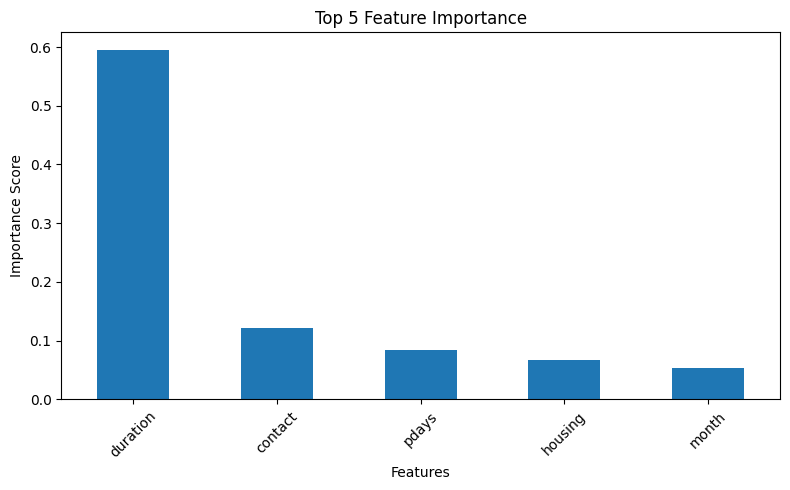

In [38]:
# Plot Feature Importance Graph

import matplotlib.pyplot as plt

# Plot top 5 important features
top5_features.plot(
    kind='bar',
    x='Feature',
    y='Importance',
    legend=False,
    figsize=(8,5)
)

plt.title("Top 5 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The feature importance values indicate how much each feature contributes to the Decision Tree's predictions.

Typically, for the Bank Marketing dataset :



*   Duration is the most influential feature because the duration of the last contact strongly affects whether a customer subscribes to a term deposit.
*   Contact is also important, as the method of contacting customers can influence response rates.
*   Poutcome (outcome of the previous marketing campaign) helps predict customer behavior based on past interactions.
*   Age contributes by capturing differences in customer demographics.
*   Housing (whether the customer has a housing loan) also affects the likelihood of subscribing.









### **Q15. Business Insights**

-> Based on the Decision Tree model and the important features identified (such as duration, contact, poutcome, age, and housing), the following business insights can be drawn.

1. Which type of customers are more likely to say "Yes"?

Customers are more likely to subscribe to a term deposit if they:

*   Have a longer call duration during the marketing campaign.
*   Had a successful previous marketing campaign outcome (poutcome).
*   Are contacted through a more effective communication channel (contact).
*   Belong to age groups that have shown a higher response rate in the dataset.
*   Do not have a housing loan (if housing is identified as an important feature).


2. What strategy should a bank use?

The bank can improve its marketing campaign by:

*   Targeting customers who responded positively in previous campaigns, as they are more likely to subscribe again.
*   Using the most effective contact method (e.g., mobile or telephone) identified by the model.
*   Training sales representatives to have meaningful customer conversations, as longer and more engaging calls are associated with higher subscription rates.
*   Prioritizing customers with characteristics similar to those who previously subscribed, based on the important features identified by the model.
*   Reducing marketing efforts on low-probability customers and focusing resources on customers who are more likely to respond positively.






